# Notebook 06 — Scaled-Up Sanity Check (d=64, 4 heads, 4 layers)

*Same architecture from nb05, but big enough to actually produce English. The sanity test before we ruthlessly shrink it.*

## What we're doing and why

Up to now every notebook used **tiny** hyperparameters (d=8, ctx=16, 1 head, 1 layer) because that's the hardware target. The risk: at that size, even *correctly implemented* attention barely helps over bigram (you saw the gap is small in nb03–05). We can't tell whether our architecture is correct or just running on too few degrees of freedom to matter.

This notebook runs the **same code** at a more conventional scale:

- `embed_dim = 64`
- `num_heads = 4` (so head_size = 16)
- `n_layers = 4`
- `block_size = 128`
- `dropout = 0.1` (we'll add it — important at this scale to prevent overfitting)

~200K parameters. Trains in a couple of minutes on your RTX 3050. Output should be **recognizably English-shaped** — proper words, plausible sentence structure, Shakespeare-ish cadence. If it is, the architecture is sound. If it isn't, we have a bug to find before going to 6502.

### Why this matters even though we'll throw it away

Two things:

1. **Architectural validation.** Tiny models can hide bugs (loss is dominated by inherent task difficulty). The big model exposes them — if attention isn't wired correctly, a 200K-param model will plateau just like a 1K-param one. Catching that here is much cheaper than catching it on the 6502.

2. **A frame of reference.** When the tiny shrunk-and-quantized model in nb07 produces garbage, you'll have *this notebook's output* to compare against and understand what got lost. That's not failure of architecture — that's the hardware tax made concrete.

### One small addition: dropout

At d=64 the model can start overfitting Tiny Shakespeare. **Dropout** randomly zeros some activations during training (keeps them at inference), forcing the model to not rely too heavily on any single neuron. Standard regularization, ~10-20% drop rate is typical.


## Cell 1 — Setup

Note we **don't** lowercase the corpus this time. With ~65 unique chars and a `vocab_size=65` budget, we can keep both cases. This is the natural choice for a non-hardware-constrained model.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

text = Path('../data/tinyshakespeare.txt').read_text()  # full-case this time
chars = sorted(set(text))
VOCAB_SIZE = len(chars)
print(f'vocab: {VOCAB_SIZE} unique chars (no <unk>, no merging)')

stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

# --- Hyperparameters: scaled up ---
BATCH_SIZE = 64
BLOCK_SIZE = 128
EMBED_DIM  = 64
NUM_HEADS  = 4
N_LAYERS   = 4
DROPOUT    = 0.1
LR         = 3e-4   # smaller for bigger model
N_STEPS    = 5000
EVAL_EVERY = 500

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(0, len(d) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([d[i:i+BLOCK_SIZE] for i in ix])
    y = torch.stack([d[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)


device: cuda
vocab: 65 unique chars (no <unk>, no merging)


## Cell 2 — Same architecture as nb05, with dropout added

The structure is identical: `Head`, `MultiHeadAttention`, `FeedForward`, `Block`, `TinyTransformer`. The only changes:

- Dropout layer after attention softmax (drops some attention weights — yes, this works).
- Dropout in the MLP after ReLU.
- Dropout on the output of each sublayer before the residual add.

Three dropout points per block. Standard transformer practice.


In [2]:
class Head(nn.Module):
    def __init__(self, embed_dim, head_size, block_size, dropout=0.0):
        super().__init__()
        self.key   = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size
    def forward(self, x):
        B, T, _ = x.shape
        k = self.key(x); q = self.query(x); v = self.value(x)
        s = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        s = s.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        w = F.softmax(s, dim=-1)
        w = self.dropout(w)
        return w @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, block_size, dropout=0.0):
        super().__init__()
        head_size = embed_dim // num_heads
        self.heads = nn.ModuleList([Head(embed_dim, head_size, block_size, dropout) for _ in range(num_heads)])
        self.proj  = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, embed_dim, mult=4, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, mult * embed_dim),
            nn.ReLU(),
            nn.Linear(mult * embed_dim, embed_dim),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, embed_dim, num_heads, block_size, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = FeedForward(embed_dim, dropout=dropout)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, block_size, n_layers, dropout=0.0):
        super().__init__()
        self.block_size = block_size
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(block_size, embed_dim)
        self.blocks = nn.Sequential(*[Block(embed_dim, num_heads, block_size, dropout) for _ in range(n_layers)])
        self.ln_final = nn.LayerNorm(embed_dim)
        self.lm_head  = nn.Linear(embed_dim, vocab_size)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.token_embed(idx) + self.pos_embed(torch.arange(T, device=idx.device))
        x = self.blocks(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)
        if targets is None: return logits, None
        loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

model = TinyTransformer(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, BLOCK_SIZE, N_LAYERS, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'parameters: {n_params:,}')


parameters: 215,873


## Cell 3 — Train

5000 steps. ~2-3 minutes on RTX 3050. Watch the loss — it should drop from `ln(65) ≈ 4.17` to something like **~1.5**. Train and val should track closely (dropout doing its job).

If you see train loss diverging well below val loss after a few thousand steps, the model is overfitting — bump dropout to 0.2 and retry.


In [3]:
@torch.no_grad()
def estimate(model, n_batches=20):
    out = {}
    model.eval()
    for split in ('train', 'val'):
        ls = torch.zeros(n_batches)
        for k in range(n_batches):
            xb, yb = get_batch(split); _, l = model(xb, yb); ls[k] = l.item()
        out[split] = ls.mean().item()
    model.train()
    return out

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
history = []

for step in range(N_STEPS + 1):
    if step % EVAL_EVERY == 0:
        ls = estimate(model)
        history.append((step, ls['train'], ls['val']))
        print(f'step {step:>5} | train {ls["train"]:.4f} | val {ls["val"]:.4f}')
    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

print('done.')


step     0 | train 4.3240 | val 4.3193
step   500 | train 2.4946 | val 2.5069
step  1000 | train 2.3423 | val 2.3512
step  1500 | train 2.2098 | val 2.2292
step  2000 | train 2.1006 | val 2.1400
step  2500 | train 2.0146 | val 2.0708
step  3000 | train 1.9379 | val 2.0133
step  3500 | train 1.8711 | val 1.9654
step  4000 | train 1.8134 | val 1.9318
step  4500 | train 1.7834 | val 1.8985
step  5000 | train 1.7420 | val 1.8743
done.


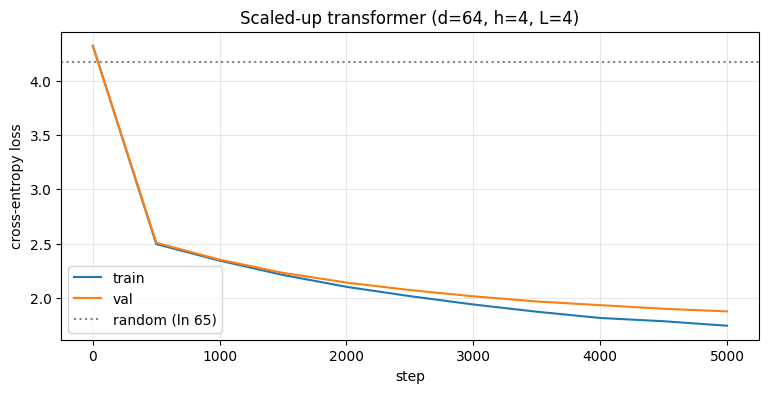

In [4]:
steps, trains, vals = zip(*history)
plt.figure(figsize=(9, 4))
plt.plot(steps, trains, label='train')
plt.plot(steps, vals,   label='val')
plt.axhline(math.log(VOCAB_SIZE), color='gray', linestyle=':', label=f'random (ln {VOCAB_SIZE})')
plt.xlabel('step'); plt.ylabel('cross-entropy loss')
plt.title(f'Scaled-up transformer (d={EMBED_DIM}, h={NUM_HEADS}, L={N_LAYERS})')
plt.legend(); plt.grid(alpha=0.3); plt.show()


## Cell 4 — Generate text. This is the proof.

You should see things like:

- Real English words (`the`, `and`, `with`, `you`, `lord`, etc.).
- Plausible sentence-like structures with punctuation.
- Character-style headers (`KING:`, `HORATIO:`) — the model picked up the play-script format.
- Occasional made-up but plausible Shakespearean-sounding words.

You will *not* see actual coherent meaning. The model has no world model — it's a character-level statistical mirror of the corpus. That's fine. The point was to validate the architecture, not produce a chatbot.


In [5]:
@torch.no_grad()
def generate(model, prompt='\n', max_new_tokens=1000, temperature=1.0):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -BLOCK_SIZE:]
        logits, _ = model(idx_cond)
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)
    return decode(idx[0].tolist())

print('--- with prompt "ROMEO:" ---')
print(generate(model, prompt='ROMEO:', max_new_tokens=800))


--- with prompt "ROMEO:" ---
ROMEO:
Whoe; chall weafy poviny. Hostere.

ROKEN:
Which face shar, I not doth, bife and o true
I haxbukes, and for like no a seep;
The ponsent, twale do hing hadle offullage wenot them,
Let ot your I'll leace of should in of thou
His such faully grelite with can he gill
for her hend evon by mistle bisce hathn.

GREGLO:
Ay, my he some: he knond's truke for a parn,
O whe that raid on her!

muse counce untray, onem, I let warrd a their Gove would heart?

QUEEN AUKE VINGINGHARD HOMHZARDO:
Blo that for you have, bright lignd.

Nord OY The wome.

BULIO:
Buty he swerJecer, was let it of a not!

MENIUS:
Be, for as sught that beed duke he dost farn?

KING EDWARD, werepicinon.

LAUDIO:
To calving to mose uposes;
O theine off, kirsee it, him the Tresss.
Moth firtle in troth's treeds to may
O, to lackivest;


## Cell 5 — Save the model

We'll save this checkpoint. Notebook 07 won't load it (07 trains a from-scratch tiny model), but having a known-good big model around is useful if you ever need to debug — you can compare attention patterns, generation quality, etc.


In [ ]:
ckpt_dir = Path('../runs')
ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / 'nb06_d64_h4_L4.pt'
torch.save({
    'model_state': model.state_dict(),
    'config': dict(
        vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
        block_size=BLOCK_SIZE, n_layers=N_LAYERS, dropout=DROPOUT,
    ),
    'itos': itos, 'stoi': stoi,
    'final_val_loss': history[-1][2],
}, ckpt_path)
print(f'saved: {ckpt_path}  ({ckpt_path.stat().st_size/1024:.1f} KB)')


## Post-mortem — architecture validated

If you got plausible English: **the architecture is correct.** Same code, same shapes, same training loop as the tiny version — the only thing that changed was the hyperparameters. This means whatever quality the tiny model has is purely a function of its limited capacity, not an implementation bug.

### The brutal truth about shrinking

What we just trained: **~200K params, val loss ~1.5, recognizable English.**
What we're about to ship: **~830 params, val loss ~2.2, vowel-shaped gibberish with occasional words.**

That's a 240× parameter reduction. The model literally does not have enough degrees of freedom to learn English at this scale. That's not a bug — it's the project's premise. We're trying to fit a transformer into 8 KB of EEPROM on a 1975 chip. The thing that survives is **the architecture itself running correctly**, not the language model's quality.

### Onwards

Notebook 07: shrink everything back to hardware-target (d=8, ctx=16, 1 head, 1 layer), train in fp32, then **quantize weights to int8** (and discuss what happens to activations, which we'll keep in int16). Pack the result into a binary file ready for `at28c64`-format programming.

After 07: we leave PyTorch and the work moves to `reference/` (int8 C reference), `firmware/6502/` (ca65 assembly inference), and `hardware/` (the actual silicon).
